# ASDEA_sensors -- complete showcase

Everything the package can do, on one window, written to be followed step by
step. Conventions used here:

* tunable values are plain variables named with a leading underscore
  (`_time_start`, `_device`, `_fmin`, ...), so they are easy to spot;
* every function is called with its inputs one per line, so you see what can
  be passed;
* image saving (`save=...`) is left commented so nothing is written to disk;
* no hidden loops -- single-sensor work uses the chain
  `ds.<sensor>.get_window(...).baseline().filter(...)`, multi-sensor work uses
  the list helpers (`..._all`).

## 0. Imports

In [1]:
%matplotlib inline

import numpy as np
from datetime import datetime

from asdea_sensors import SensorDataset
from asdea_sensors.config import settings

## 1. Read the data (only read)

In [2]:
_folder = r"C:\Users\ppala\Desktop\02_31MAY2026"

ds = SensorDataset(_folder, verbose=True)
print("devices    :", ds.devices)
print("max points :", format(ds.max_points, ","))

------------------------------------------------------------
SensorDataset
------------------------------------------------------------
path        : C:\Users\ppala\Desktop\02_31MAY2026
files       : 32
time span   : 2026-05-31 14:52:12  ->  2026-05-31 20:02:13
duration    : 18601.0 s
devices     : MNAT0031, MNAT0034, MOF00134, MOF00135, MOF00136
fs / dt     : 252.5885 Hz / 0.003959 s
max points  : 4,836,520 samples/axis (largest device)
------------------------------------------------------------
axes (per sensor):
  MNAT0031   -> (3, 1, 5)
  MNAT0034   -> (3, 1, 5)
  MOF00134   -> (0, 1, 2)
  MOF00135   -> (3, 1, 5)
  MOF00136   -> (3, 1, 5)
------------------------------------------------------------
on-disk size: 782.17 MB
RAM         : used 15.01 GB / avail 18.50 GB (45%)
------------------------------------------------------------
devices    : ['MNAT0031', 'MNAT0034', 'MOF00134', 'MOF00135', 'MOF00136']
max points : 4,836,520


## 2. Resample to a uniform dt (before any treatment)

Every read from here on comes out at this `dt`, for all sensors.

In [3]:
_dt = 0.004                 # target sampling interval [s]  (fs = 250 Hz)
_fs = round(1.0 / _dt)

ds = ds.resample(dt=_dt)
print("uniform dt =", _dt, "s   ->   fs =", _fs, "Hz")

uniform dt = 0.004 s   ->   fs = 250 Hz


## 3. Overview of every sensor + the window to analyse

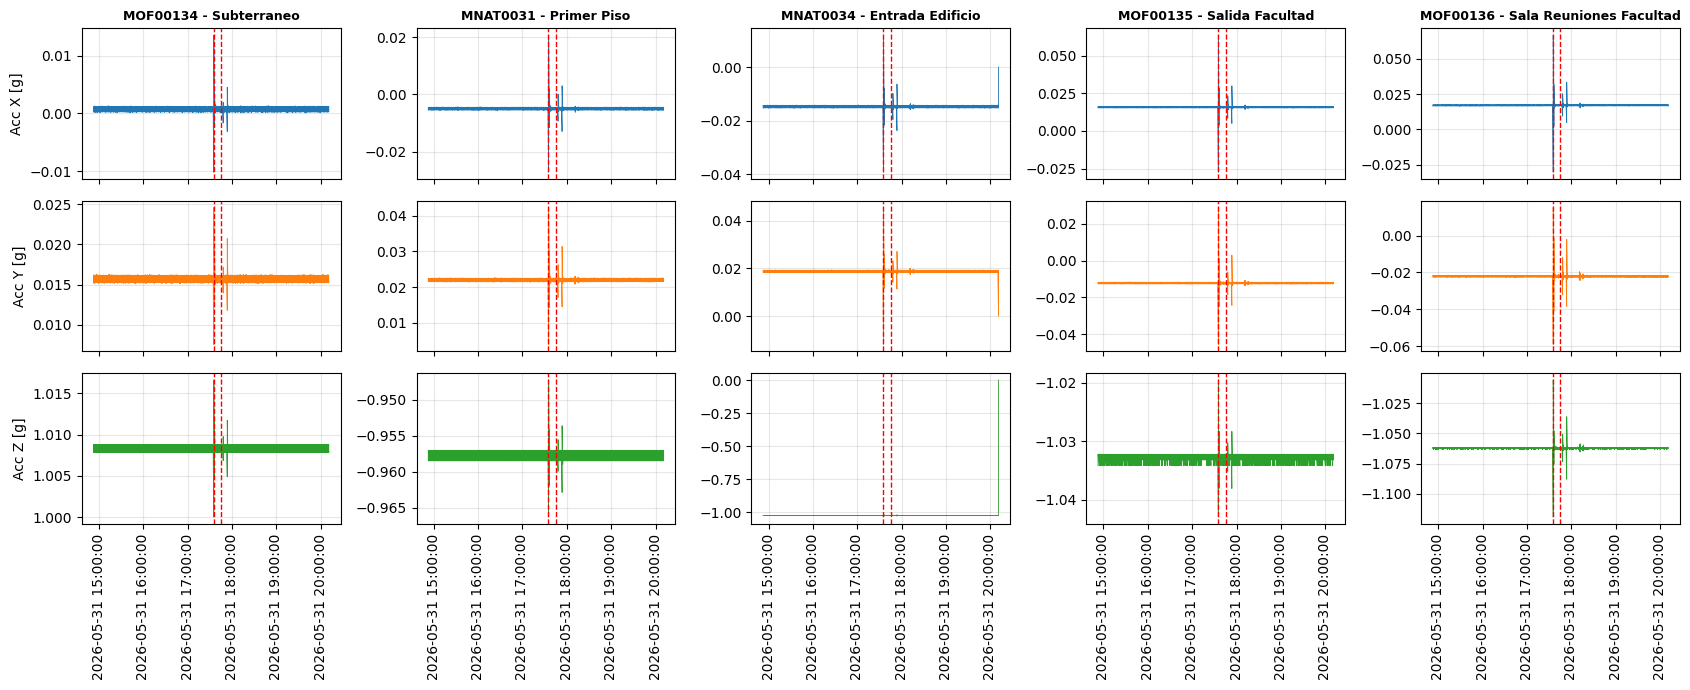

In [4]:
from asdea_sensors.plotting import overview_plots

_time_start = datetime(2026, 5, 31, 17, 35, 0)
_time_end   = datetime(2026, 5, 31, 17, 45, 0)

_devices = ["MOF00134", "MNAT0031", "MNAT0034", "MOF00135", "MOF00136"]

_titles = {
    "MOF00134": "Subterraneo",
    "MNAT0031": "Primer Piso",
    "MNAT0034": "Entrada Edificio",
    "MOF00135": "Salida Facultad",
    "MOF00136": "Sala Reuniones Facultad",
}

overview_plots.plot_overview(
    ds,
    devices=_devices,
    titles=_titles,
    factor=1.0,                # raw is g; 9.81 for m/s^2
    unit="g",
    window=(_time_start, _time_end),
    figsize=(17, 7),
    # save="overview.pdf",
)

## 4. Take the window for one sensor (the chain)

`ds.<sensor>.get_window(...)` returns a handle; `.signal()` reads only the
window. This is the per-sensor chain everything else is built on.

In [5]:
_device = "MNAT0034"

_handle = ds.device(_device).get_window(_time_start, _time_end)
_sig    = _handle.signal(components="all")

print("%s : %d samples, %.1f s, dt=%.6f s" % (_device, _sig.n, _sig.duration, _sig.dt))
print("from %s to %s" % (_sig.t_abs[0], _sig.t_abs[-1]))

[signal] MNAT0034 n=150001 dt=0.004000 comps=all
MNAT0034 : 150001 samples, 600.0 s, dt=0.004000 s
from 2026-05-31T17:35:00.000000000 to 2026-05-31T17:45:00.000000000


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MNAT0034' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


## 5. Accelerogram of that sensor (in g)

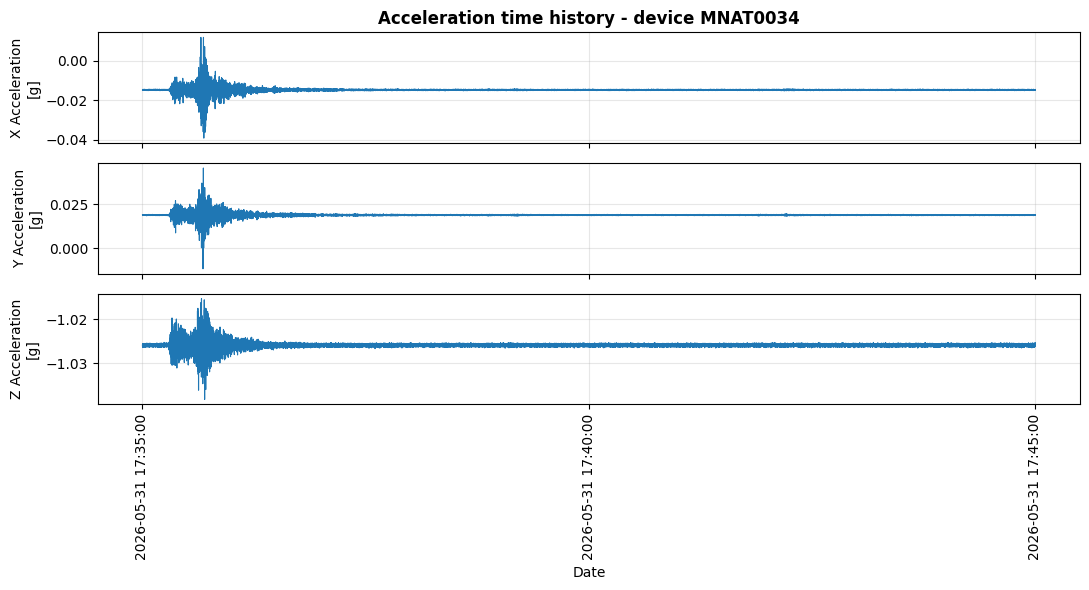

In [6]:
from asdea_sensors.plotting import signal_plots

signal_plots.plot_signals(
    _sig,
    components="all",       # "x" | "y" | "z" | "all"
    kind="acc",             # "acc" | "vel" | "disp"
    factor=1/9.81,          # m/s^2 -> g
    unit="g",
    time_axis="absolute",   # "absolute" (real date) | "relative" (seconds)
    figsize=(11, 6),
    xlim=None,
    ylim=None,
    # save="acc_one.pdf",
)

## 6. Accelerogram of all sensors overlaid (one call, no loop)

[signal] MOF00134 n=150001 dt=0.004000 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MNAT0031' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MNAT0031 n=150001 dt=0.004000 comps=all


[signal] MNAT0034 n=150001 dt=0.004000 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MOF00135' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MOF00135 n=150001 dt=0.004000 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MOF00136' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MOF00136 n=150001 dt=0.004000 comps=all


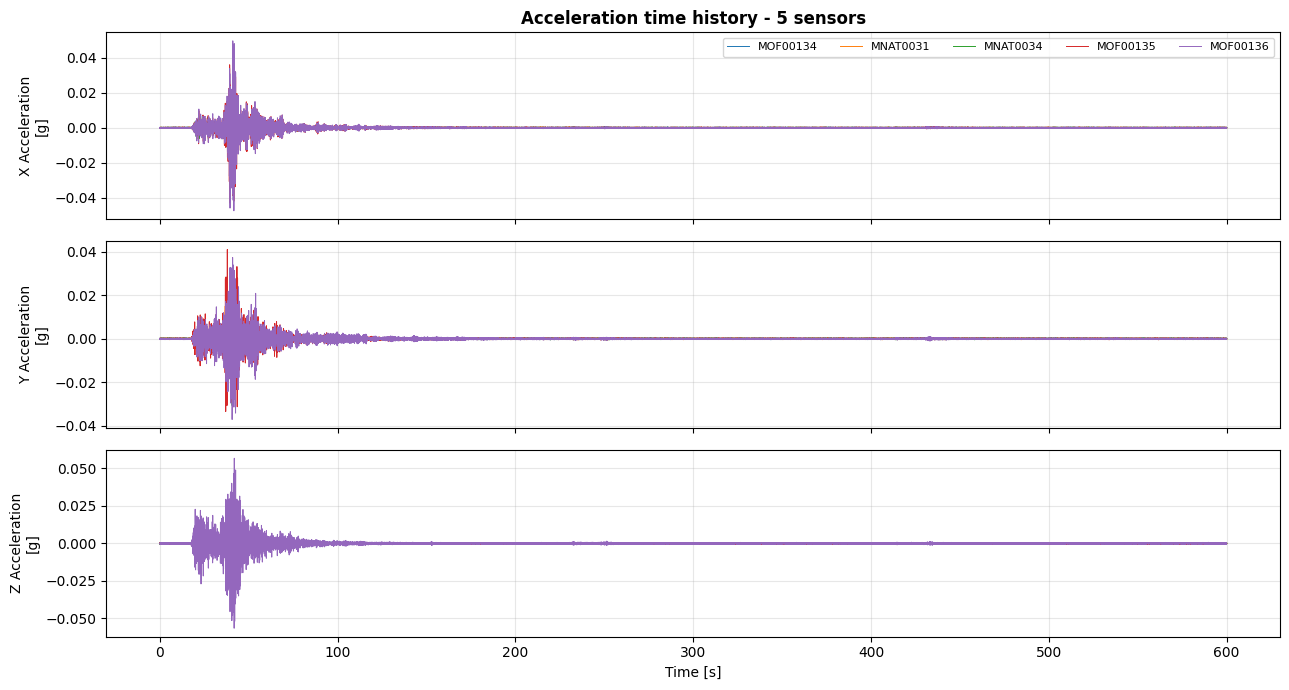

In [7]:
signal_plots.plot_signals_all(
    ds,
    devices=_devices,
    start_time=_time_start,
    end_time=_time_end,
    components="all",
    kind="acc",
    factor=1/9.81,
    unit="g",
    time_axis="relative",
    baseline=True,          # remove DC offset so the overlay is comparable
    fmin=None,
    fmax=None,
    group=True,             # overlay sensors; False -> one figure each
    figsize=(13, 7),
    xlim=None,
    ylim=None,
    # save="png",
)

## 7. Corrections and band-pass (the chain)

Decoupled steps: baseline correction, then band-pass, then integration to
velocity and displacement.

In [8]:
_fmin, _fmax = 0.2, 20.0     # band-pass edges [Hz]

_proc = (ds.device(_device).get_window(_time_start, _time_end)
           .baseline()
           .filter(_fmin, _fmax, engine="scipy")
           .derive())
_sig_p = _proc.signal(components="all")
print("processed: acc/vel/disp ready ->", _sig_p.vel_x is not None)

[signal] MNAT0034 n=150001 dt=0.004000 comps=all
processed: acc/vel/disp ready -> True


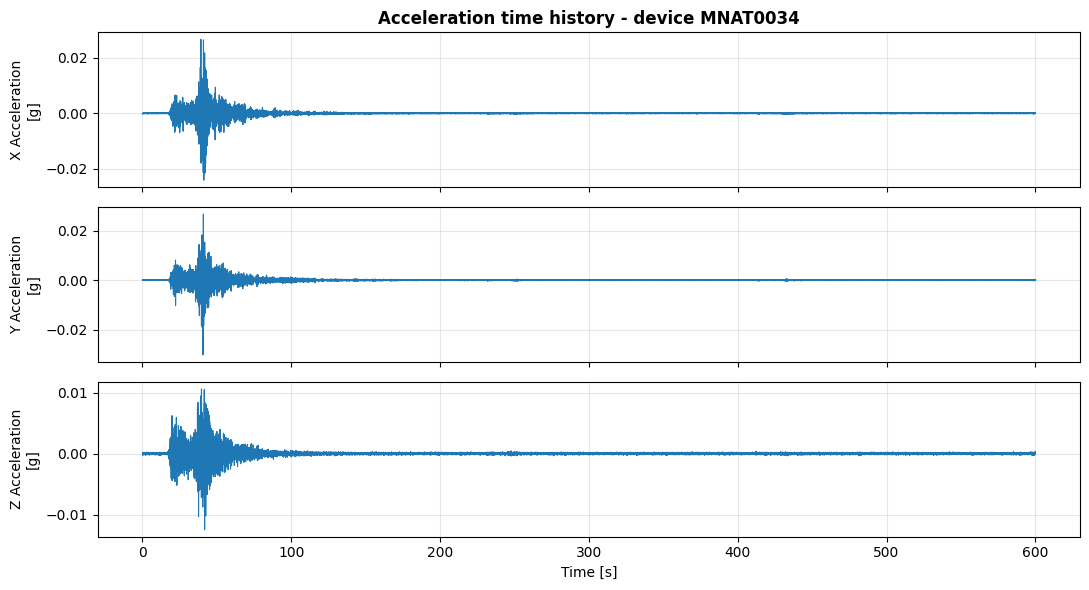

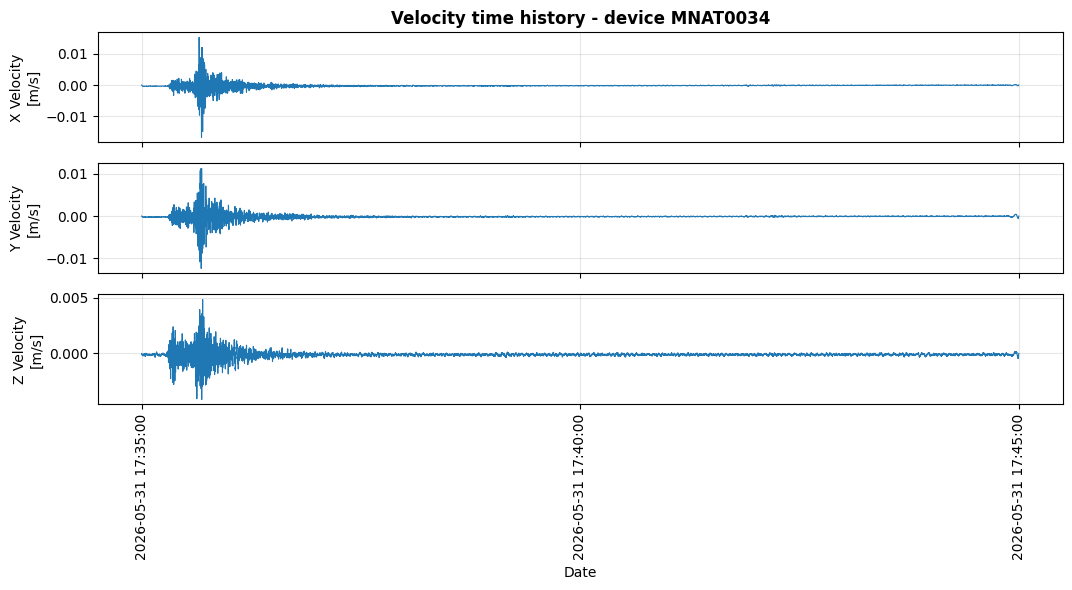

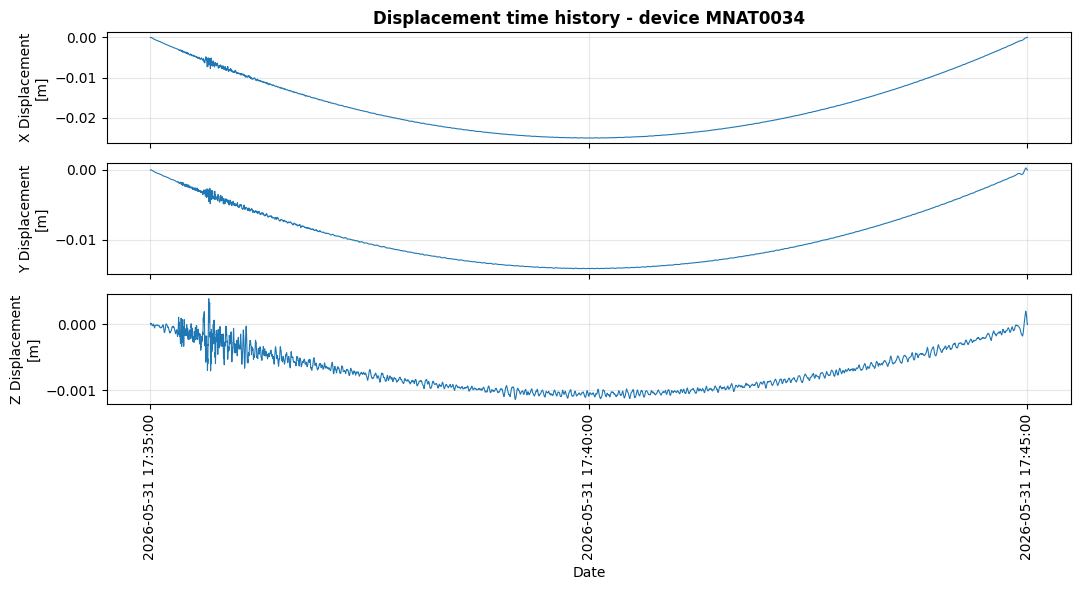

In [9]:
signal_plots.plot_signals(_sig_p, components="all", kind="acc",  factor=1/9.81, unit="g",
                          time_axis="relative", figsize=(11, 6))
signal_plots.plot_signals(_sig_p, components="all", kind="vel",  figsize=(11, 6))
signal_plots.plot_signals(_sig_p, components="all", kind="disp", figsize=(11, 6))

## 8. Fourier amplitude spectrum (raw vs filtered)

[signal] MNAT0034 n=150001 dt=0.004000 comps=all


[signal] MNAT0034 n=150001 dt=0.004000 comps=all


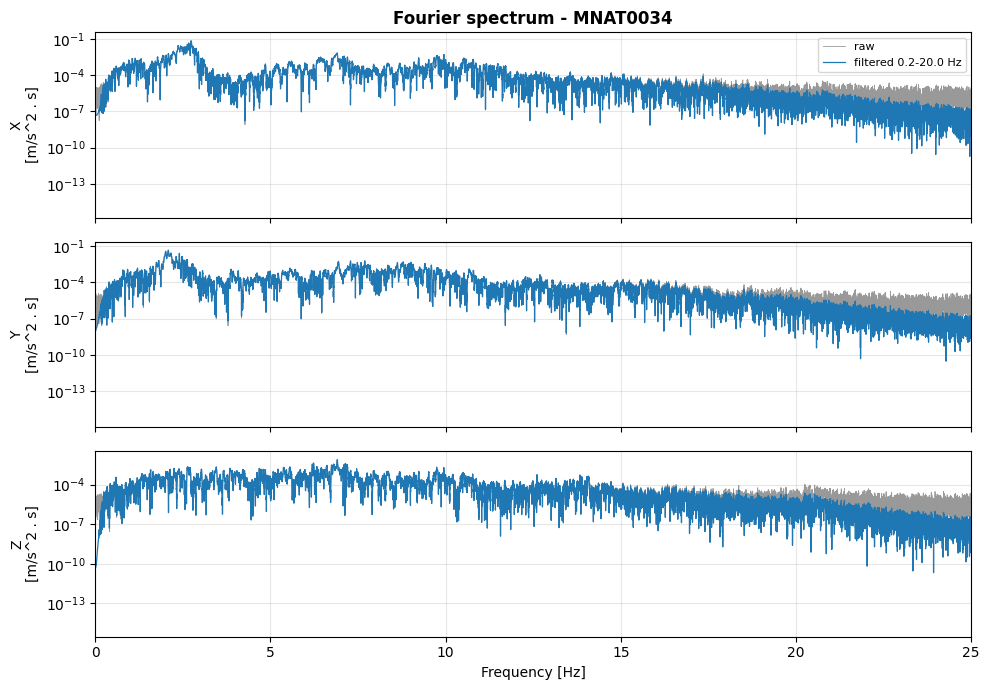

[None]

In [10]:
from asdea_sensors.plotting import fourier_plots

fourier_plots.plot_fourier_all(
    ds,
    devices=[_device],
    start_time=_time_start,
    end_time=_time_end,
    components=("x", "y", "z"),
    baseline=True,
    fmin=_fmin,
    fmax=_fmax,
    smooth=None,            # or "konno"
    overlay_raw=True,       # grey = raw, blue = filtered
    group=False,
    figsize=(10, 7),
    xlim=(0, 25),
    # save="fourier_compare.pdf",
)

## 9. Fourier of all sensors (filtered, overlaid per component)

[signal] MOF00134 n=150001 dt=0.004000 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MNAT0031' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MNAT0031 n=150001 dt=0.004000 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MNAT0034' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MNAT0034 n=150001 dt=0.004000 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MOF00135' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MOF00135 n=150001 dt=0.004000 comps=all


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MOF00136' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MOF00136 n=150001 dt=0.004000 comps=all


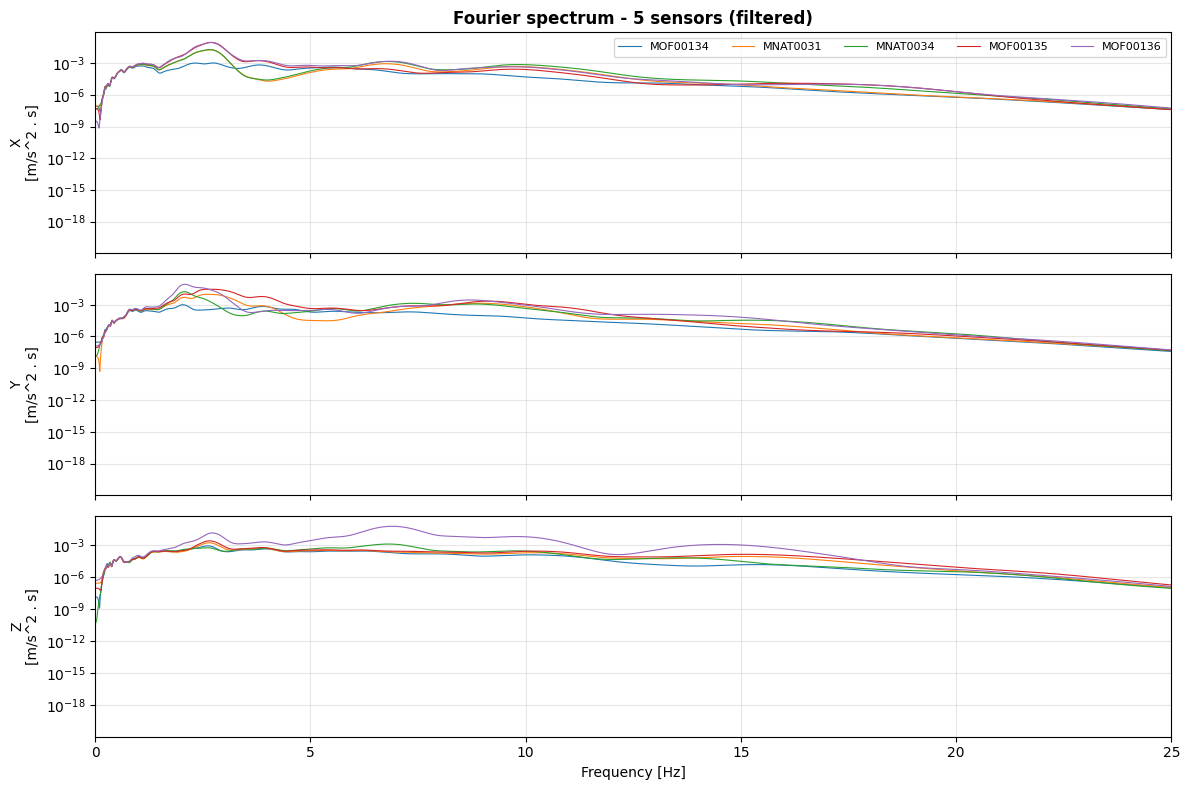

In [11]:
fourier_plots.plot_fourier_all(
    ds,
    devices=_devices,
    start_time=_time_start,
    end_time=_time_end,
    components=("x", "y", "z"),
    baseline=True,
    fmin=_fmin,
    fmax=_fmax,
    smooth="konno",
    overlay_raw=False,
    group=True,
    figsize=(12, 8),
    xlim=(0, 25),
)

## 10. Newmark response spectra (PSa, PSv, Sd) in g

[newmark] MNAT0034 comp=x zeta=0.05 Tmax=3.0 dT=0.01 -> 300 periods (computed)


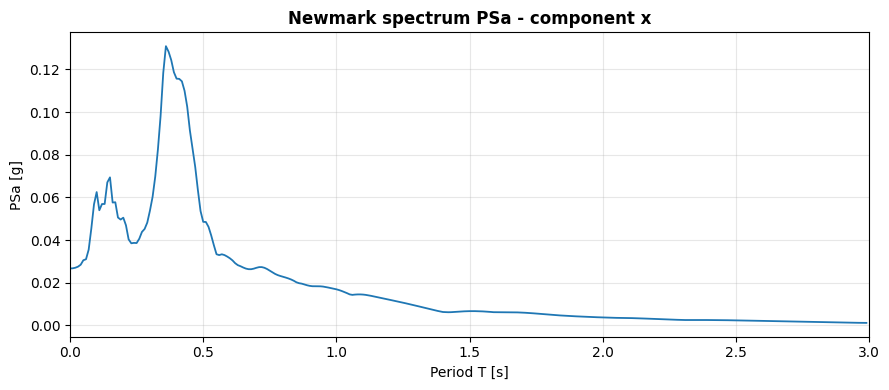

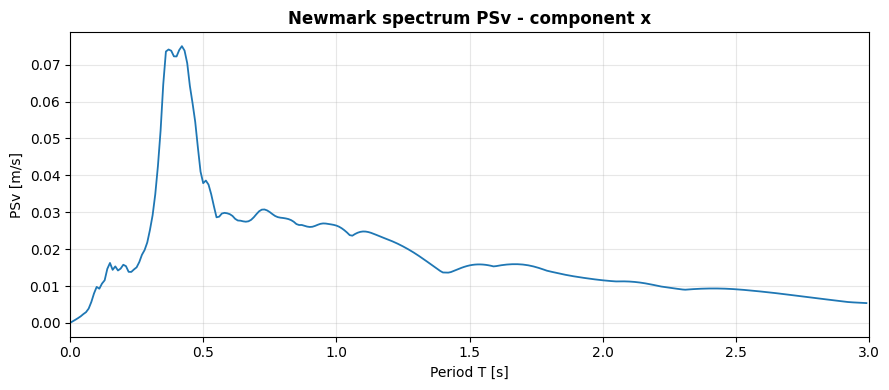

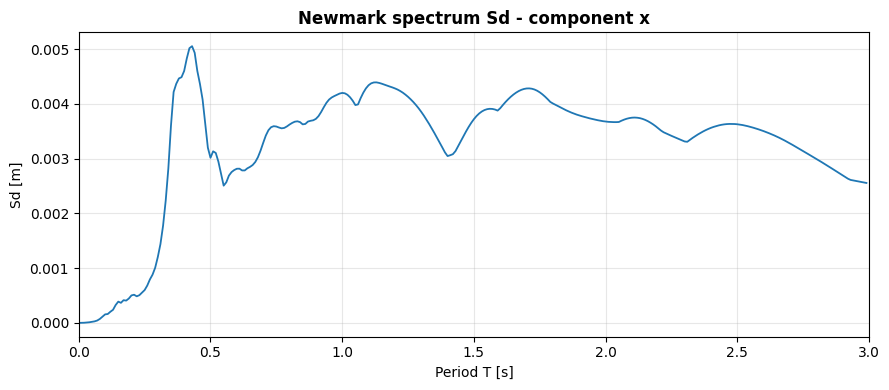

In [12]:
from asdea_sensors.plotting import newmark_plots

_zeta = 0.05
_spec = (ds.device(_device).get_window(_time_start, _time_end)
           .baseline().filter(_fmin, _fmax, engine="scipy")
           .newmark(
               component="x",
               zeta=_zeta,
               max_period=3.0,
               dT=0.01,
               factor=1/9.81,     # PSa, Sa in g
           ))

newmark_plots.plot_newmark(_spec, component="x", quantity="PSa", unit="g",
                           figsize=(9, 4), xlim=(0, 3))
newmark_plots.plot_newmark(_spec, component="x", quantity="PSv",
                           figsize=(9, 4), xlim=(0, 3))
newmark_plots.plot_newmark(_spec, component="x", quantity="Sd",
                           figsize=(9, 4), xlim=(0, 3))

## 11. RotD spectra (0 / 50 / 100)

C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MNAT0034' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[rotd] MNAT0034 x/y rotd=50 -> 150 periods (computed)


[rotd] MNAT0034 x/y rotd=0 -> 150 periods (computed)


[rotd] MNAT0034 x/y rotd=100 -> 150 periods (computed)


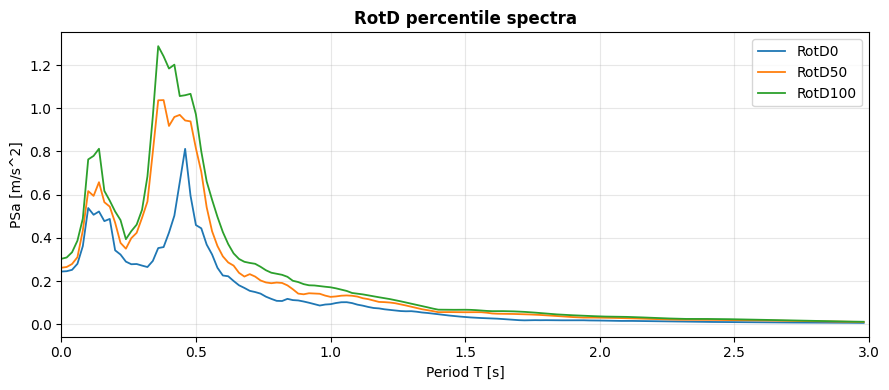

In [13]:
from asdea_sensors.plotting import rotd_plots

_wf = ds.device(_device).get_window(_time_start, _time_end).baseline().filter(_fmin, _fmax, engine="scipy")
_r50  = _wf.rotd(comp_x="x", comp_y="y", rotd=50,  angle_step=15, max_period=3.0, dT=0.02)
_r0   = _wf.rotd(rotd=0,   angle_step=15, max_period=3.0, dT=0.02)
_r100 = _wf.rotd(rotd=100, angle_step=15, max_period=3.0, dT=0.02)
_merged = {"T": _r50["T"], "ROTD0": _r0["ROTD0"], "ROTD50": _r50["ROTD50"], "ROTD100": _r100["ROTD100"]}

rotd_plots.plot_rotd(_merged, rotd=(0, 50, 100), figsize=(9, 4), xlim=(0, 3))

## 12. Intensity measures: Arias, CAV, Housner, peaks

C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MNAT0034' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[arias] MNAT0034 comp=x low=5 high=95 (computed)


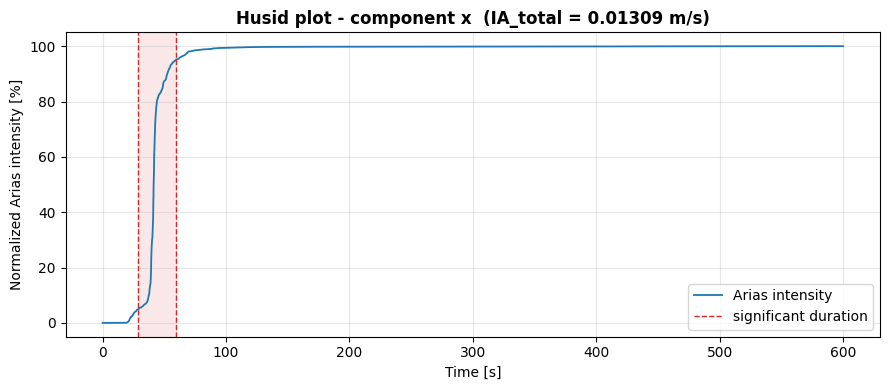

[cav] MNAT0034 comp=x (computed)
CAV    = 1.74864


[housner] MNAT0034 comp=x T1=0.1 T2=2.5 (computed)
SI     = 0.051381
[peaks] MNAT0034 comp=x PGA=0.2615 (computed)
[peaks] MNAT0034 comp=y PGA=0.2966 (computed)
[peaks] MNAT0034 comp=z PGA=0.1222 (computed)
peaks  = {'PGA': 0.26147, 'PGV': 0.01679, 'PGD': 0.0251}


In [14]:
from asdea_sensors.plotting import arias_plots

_wfd = ds.device(_device).get_window(_time_start, _time_end).baseline().filter(_fmin, _fmax, engine="scipy").derive()

_arias = dict(_wfd.arias(component="x", low=5, high=95)); _arias["dt"] = _dt
arias_plots.plot_arias(_arias, component="x", figsize=(9, 4))

print("CAV    =", round(float(_wfd.cav(component="x")["CAV"]), 5))
print("SI     =", round(float(_wfd.housner(component="x", T1=0.1, T2=2.5, zeta=_zeta)["SI"]), 6))
print("peaks  =", {k: round(float(v), 5) for k, v in _wfd.peaks(component="all")["x"].items()})

## 13. PSD with band energy, and STFT spectrogram

[psd] MNAT0034 comp=x nperseg=512 (computed)


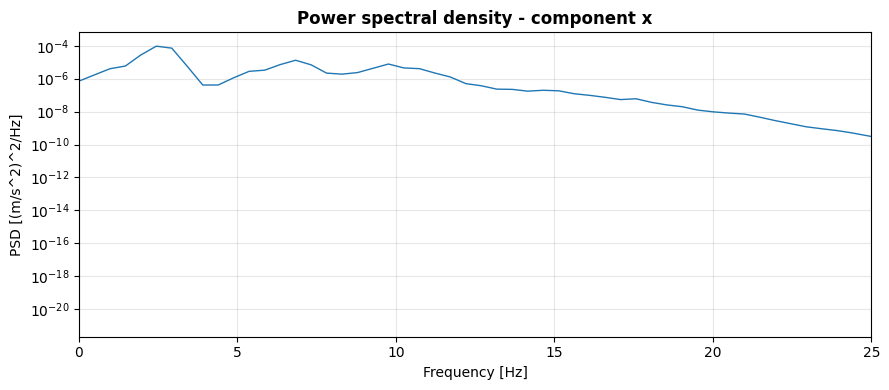

band energy: {'(0, 1)': 2e-06, '(1, 2.5)': 3.8e-05, '(2.5, 5)': 2.1e-05, '(5, 10)': 2.3e-05}
[stft] MNAT0034 comp=x nperseg=256 fmax=25.0 (computed)


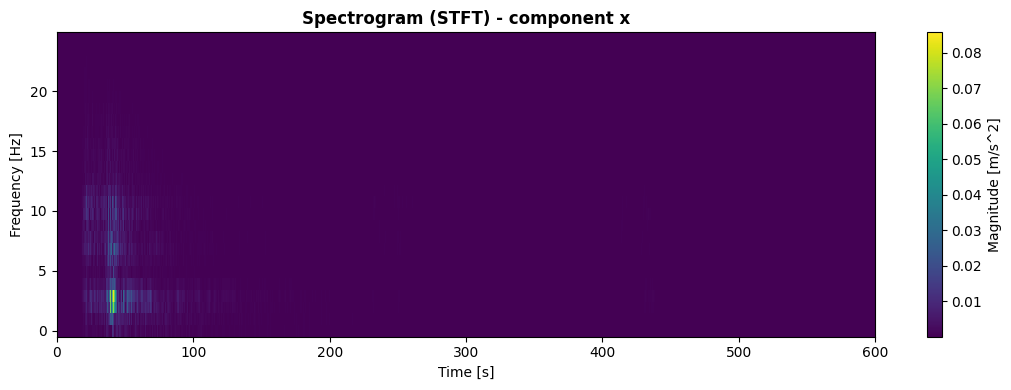

In [15]:
from asdea_sensors.plotting import psd_plots, stft_plots

_psd = _wf.psd(
    component="x",
    nperseg=512,
    noverlap=256,
    window="hann",
    bands=[(0, 1), (1, 2.5), (2.5, 5), (5, 10)],
    detrend="constant",
)
psd_plots.plot_psd(_psd, component="x", figsize=(9, 4), xlim=(0, 25))
print("band energy:", {str(k): round(float(v), 6) for k, v in _psd["band_energy"].items()})

_stft = _wf.stft(component="x", nperseg=256, noverlap=224, window="hann", fmax=25.0)
stft_plots.plot_stft(_stft, component="x", figsize=(11, 4))

## 14. Ambient analysis, step by step (see every algorithm)

Like the old `BuildPeriod` with `display_figures=True`: STA/LTA, window
selection, taper, FFT, Konno-Ohmachi smoothing and the mean spectrum, each one
visible. The config is laid out explicitly.

In [16]:
from asdea_sensors.plotting import ambient_plots

_config = {
    "Fs":   _fs,                 # sampling rate (after resample)
    "vent": 30 * 4,              # window length [s]
    "vent_seismic": False,
    "STA":  1,    "LTA": 30,     # STA/LTA windows [s]
    "vmin": 0.010, "vmax": 5.50, # STA/LTA acceptance band
    "p":    0.05,                # Tukey taper alpha
    "f1":   0.20, "f2": 20.0,    # FFT band [Hz]
    "bexp": 1e2,                 # Konno-Ohmachi smoothing constant
}

_amb = (ds.device(_device).get_window(_time_start, _time_end)
          .baseline().filter(_fmin, _fmax, engine="scipy")
          .signal()
          .ambient(_config, component="x"))

[signal] MNAT0034 n=150001 dt=0.004000 comps=all


- sta_lta: ratio computed (STA=1 s, LTA=30 s)


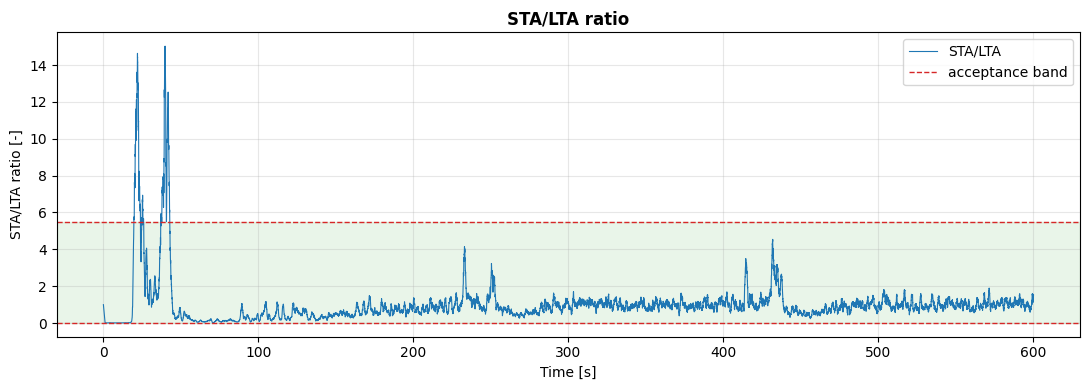

In [17]:
_amb.sta_lta()                                  # step 1: STA/LTA ratio
ambient_plots.plot_sta_lta(_amb, figsize=(11, 4))

- select_windows: 3 window(s) selected


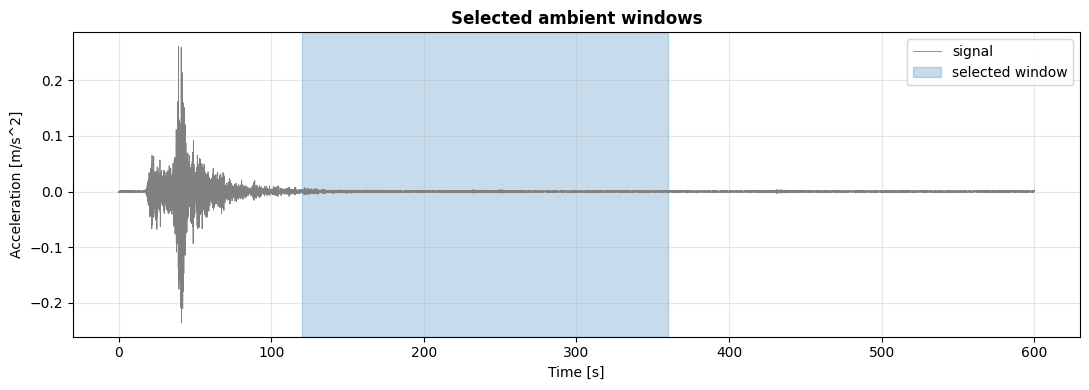

In [18]:
_amb.select_windows(manual=None)                # step 2: pick stationary windows
ambient_plots.plot_windows(_amb, figsize=(11, 4))

- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=0.3438 s)


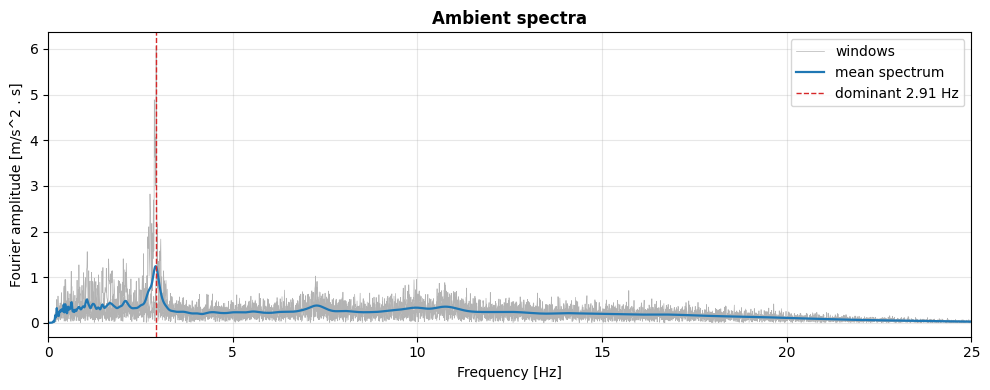

dominant period: 0.344 s  -> f0 = 2.91 Hz


In [19]:
_amb.taper()                                    # step 3: Tukey taper
_amb.fft(apply_filter=False)                    # step 4: FFT per window
_amb.smooth()                                   # step 5: Konno-Ohmachi
_amb.average()                                  # step 6: mean spectrum
ambient_plots.plot_spectrum(_amb, figsize=(10, 4), xlim=(0, 25))
print("dominant period:", round(float(_amb.dominant_period), 3), "s",
      " -> f0 =", round(1.0/_amb.dominant_period, 2), "Hz")

## 15. Predominant frequency of all sensors (ambient, overlaid)

[signal] MOF00134 n=150001 dt=0.004000 comps=all
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 3 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=0.9449 s)


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MNAT0031' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MNAT0031 n=150001 dt=0.004000 comps=all
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 3 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=0.3429 s)


...

[signal] MOF00135 n=150001 dt=0.004000 comps=all
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 2 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=0.3448 s)


C:\Dropbox\01. Brain\11. GitHub\ladruno_ASDEA_sensors\src\asdea_sensors\core\h5_reader.py:45: UserWarning: H5Reader: axes (3, 1, 5) for 'MOF00136' exceed the 3 available columns; falling back to (0, 1, 2)
  warnings.warn(


[signal] MOF00136 n=150001 dt=0.004000 comps=all
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 2 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=0.3448 s)


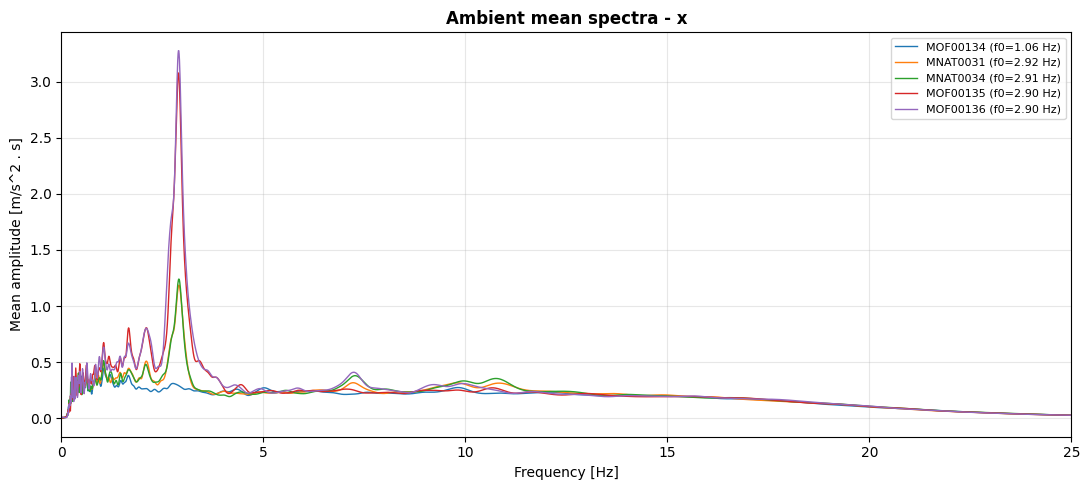

{'MOF00134': np.float64(1.0583333333333333),
 'MNAT0031': np.float64(2.9166666666666665),
 'MNAT0034': np.float64(2.908333333333333),
 'MOF00135': np.float64(2.9),
 'MOF00136': np.float64(2.9)}

In [20]:
ambient_plots.plot_mean_spectrum_all(
    ds,
    devices=_devices,
    start_time=_time_start,
    end_time=_time_end,
    config=_config,
    component="x",
    baseline=True,
    fmin=_fmin,
    fmax=_fmax,
    group=True,
    figsize=(11, 5),
    xlim=(0, 25),
)

## 16. HVSR (Nakamura) for one sensor

[signal] MNAT0034 n=150001 dt=0.004000 comps=all
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 3 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=0.3438 s)
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 2 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=0.3822 s)
- sta_lta: ratio computed (STA=1 s, LTA=30 s)
- select_windows: 3 window(s) selected
- taper: Tukey taper applied (p=0.05)
- fft: per-window FFT computed


- smooth: Konno-Ohmachi smoothing applied (bexp=100)
- average: mean spectrum computed (T=1.8462 s)


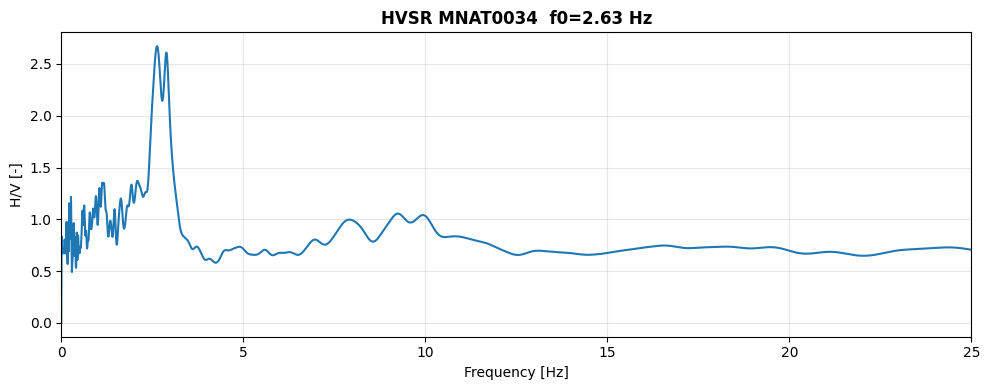

In [21]:
from asdea_sensors.ambient import hvsr
import matplotlib.pyplot as plt

_s = ds.device(_device).get_window(_time_start, _time_end).baseline().filter(_fmin, _fmax, engine="scipy").signal(components="all")
_hv = hvsr.compute(_s.acc_x, _s.acc_y, _s.acc_z, _config, combine="geometric")

plt.figure(figsize=(10, 4))
plt.plot(_hv["freqs"], _hv["HV"])
plt.xlim(0, 25)
plt.xlabel("Frequency [Hz]"); plt.ylabel("H/V [-]")
plt.title("HVSR %s  f0=%.2f Hz" % (_device, _hv["f0"]), fontweight="bold")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 17. Building correlation (structural)

Read the vertical-array sensors explicitly, then transfer function (its peaks
are the modal frequencies) and coherence (trustworthy where ~1).

[signal] MOF00134 n=150001 dt=0.004000 comps=x


[signal] MOF00135 n=150001 dt=0.004000 comps=x


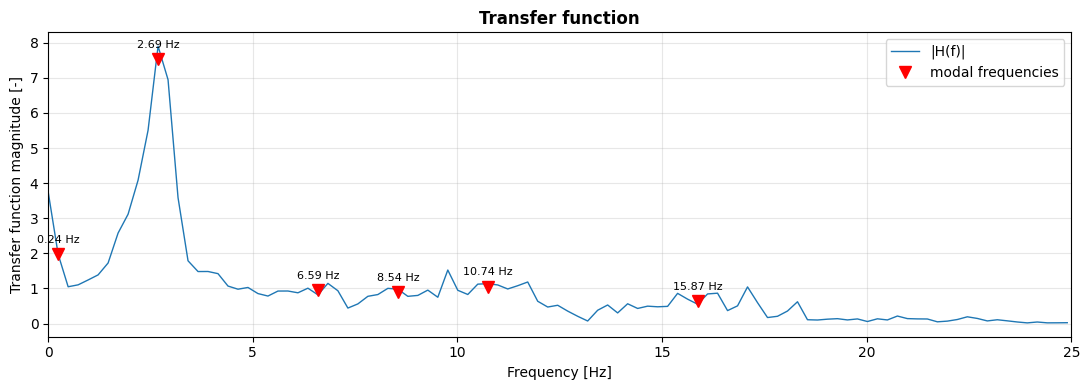

modal freqs (Hz): [0.24, 2.69, 6.59, 8.54, 10.74]


In [22]:
from asdea_sensors.building import transfer_function, coherence
from asdea_sensors.plotting import transfer_plots

_base = ds.device("MOF00134").get_window(_time_start, _time_end).baseline().filter(_fmin, _fmax, engine="scipy").signal(components="x").acc_x
_top  = ds.device("MOF00135").get_window(_time_start, _time_end).baseline().filter(_fmin, _fmax, engine="scipy").signal(components="x").acc_x
_n = min(len(_base), len(_top))

_frf = transfer_function.compute(
    _top[:_n], _base[:_n], _dt,
    estimator="H1",
    nperseg=1024,
    noverlap=512,
    smooth="konno",
    bexp=40,
    fmax=25.0,
)
transfer_plots.plot_transfer_function(_frf, figsize=(11, 4), xlim=(0, 25))
print("modal freqs (Hz):", [round(float(x), 2) for x in _frf["modal_freqs"][:5]])

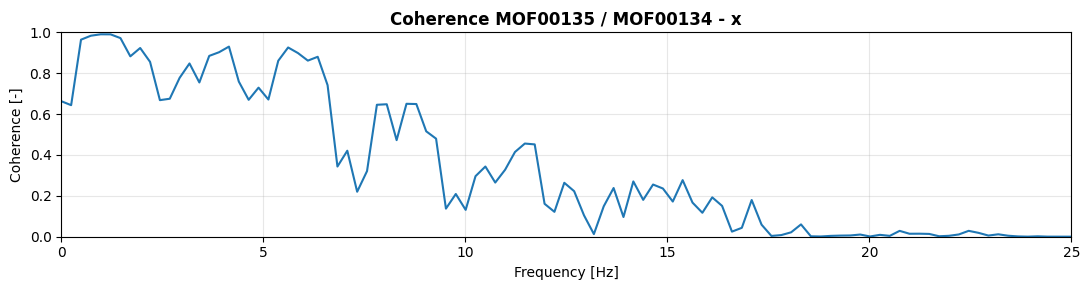

In [23]:
_coh = coherence.compute(_top[:_n], _base[:_n], _dt, nperseg=1024, noverlap=512)
plt.figure(figsize=(11, 3))
plt.plot(_coh["f"], _coh["coherence"])
plt.xlim(0, 25); plt.ylim(0, 1)
plt.xlabel("Frequency [Hz]"); plt.ylabel("Coherence [-]")
plt.title("Coherence MOF00135 / MOF00134 - x", fontweight="bold")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 18. Export everything computed to a self-describing .h5 (Provenance)

In [24]:
# import tempfile, os
# _out = os.path.join(tempfile.gettempdir(), "%s_window.h5" % _device)
# _wfd.export_h5(_out)                 # this sensor, with its cached results + Provenance
# ds.export_h5("run_window.h5")        # the whole dataset
# print("exported ->", _out)
print("export is shown commented so nothing is written to disk.")

export is shown commented so nothing is written to disk.
